In [68]:
# !pip install dataloader

In [1]:
# import kagglehub
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torch
import numpy as np
import cv2
from torch.utils.data import Dataset
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.data import Dataset, DataLoader, Subset
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt


In [3]:
device = torch.device("cuda")

In [4]:
class VGG16(nn.Module):
    def __init__(self):
        super().__init__()

        vgg = models.vgg16_bn(weights=models.VGG16_BN_Weights.IMAGENET1K_V1)

        features = list(vgg.features.children())

        self.block1 = nn.Sequential(*features[:7]) 
        self.block2 = nn.Sequential(*features[7:14])
        self.block3 = nn.Sequential(*features[14:24])
        self.block4 = nn.Sequential(*features[24:34])
        self.block5 = nn.Sequential(*features[34:44])

        self.block6 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(512, 512, kernel_size=3, padding=6, dilation=6),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        s1 = self.block1(x) 
        s2 = self.block2(s1)
        s3 = self.block3(s2)
        s4 = self.block4(s3)
        s5 = self.block5(s4)
        s6 = self.block6(s5)
        return s1, s2, s3, s4, s5, s6
    

class UpConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        mid_channels = out_channels // 2
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=1),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class CRAFT(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = VGG16()

        self.upconv1 = UpConvBlock(512 + 512, 256)
        self.upconv2 = UpConvBlock(256 + 512, 128)
        self.upconv3 = UpConvBlock(128 + 256, 64)
        self.upconv4 = UpConvBlock(64 + 128, 32)

        self.last_conv = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 16, kernel_size=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 2, kernel_size=1),
        )

        self._initialize_decoder_weights()

    def _initialize_decoder_weights(self):
        for module in [self.upconv1, self.upconv2, self.upconv3, self.upconv4, self.last_conv]:
            for m in module.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                    if m.bias is not None:
                        nn.init.constant_(m.bias, 0)
                elif isinstance(m, nn.BatchNorm2d):
                    nn.init.constant_(m.weight, 1)
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        s1, s2, s3, s4, s5, s6 = self.backbone(x)

        y = torch.cat([s6, s5], dim=1)
        y = F.interpolate(y, size=s4.shape[2:], mode="bilinear", align_corners=False)
        y = self.upconv1(y)

        y = torch.cat([y, s4], dim=1)
        y = F.interpolate(y, size=s3.shape[2:], mode="bilinear", align_corners=False)
        y = self.upconv2(y)

        y = torch.cat([y, s3], dim=1)
        y = F.interpolate(y, size=s2.shape[2:], mode="bilinear", align_corners=False)
        y = self.upconv3(y)

        y = torch.cat([y, s2], dim=1)
        y = F.interpolate(y, size=s1.shape[2:], mode="bilinear", align_corners=False)
        y = self.upconv4(y)

        y = self.last_conv(y)

        return y.permute(0, 2, 3, 1)

In [5]:
def generate_gaussian(size=64):
    x = np.linspace(-1, 1, size)
    y = np.linspace(-1, 1, size)
    xx, yy = np.meshgrid(x, y)
    gauss = np.exp(-(xx**2 + yy**2) / (2 * 0.5**2))
    return gauss.astype(np.float32)


def warp_gaussian(dst_quad, img_h, img_w, gaussian_size=64):
    src = np.array([[0,0],[64,0],[64,64],[0,64]], dtype=np.float32)
    dst = dst_quad.astype(np.float32)
    M = cv2.getPerspectiveTransform(src, dst)
    gaussian = generate_gaussian(gaussian_size)
    return cv2.warpPerspective(gaussian, M, (img_w, img_h))

def make_heatmaps(charBB, img_h, img_w):
    region = np.zeros((img_h, img_w), dtype=np.float32)
    affinity = np.zeros((img_h, img_w), dtype=np.float32)

    boxes = charBB.transpose(2, 1, 0)

    for i, box in enumerate(boxes):
        region = np.maximum(region, warp_gaussian(box, img_h, img_w))

        if i + 1 < len(boxes):
            next_box = boxes[i + 1]
            aff_quad = np.array([
                (box[0] + box[1]) / 2,
                (next_box[0] + next_box[1]) / 2,
                (next_box[2] + next_box[3]) / 2,
                (box[2] + box[3]) / 2,
            ])
            affinity = np.maximum(affinity, warp_gaussian(aff_quad, img_h, img_w))

    return region, affinity


In [6]:
class SynthTextDataset(Dataset):
    def __init__(self, root, img_size=768):
        self.root = Path(root)
        self.img_size = img_size

        mat = sio.loadmat(str(self.root / "gt.mat"), squeeze_me=True, struct_as_record=False)
        self.imnames = mat["imnames"]
        self.charBBs = mat["charBB"]
        self.img_size = img_size

    def __getitem__(self, idx):
        img_path = self.root / self.imnames[idx]
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w = img.shape[:2]
        charBB = self.charBBs[idx]
        if charBB.ndim == 2:          # single character edge case
            charBB = charBB[:, :, None]

        # Resize image
        scale = self.img_size / max(h, w)
        new_h, new_w = int(h * scale), int(w * scale)
        img = cv2.resize(img, (new_w, new_h))

        # Scale charBB coords
        charBB = charBB.copy().astype(np.float32)
        charBB[0] *= (new_w / w)   # x
        charBB[1] *= (new_h / h)   # y

        # Heatmaps are at half resolution (CRAFT output is H/2)
        hm_h, hm_w = new_h // 2, new_w // 2
        charBB_half = charBB / 2.0
        region, affinity = make_heatmaps(charBB_half, hm_h, hm_w)

        # Pad image to square
        pad_img = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        pad_img[:new_h, :new_w] = img

        # Pad heatmaps
        hm_size = self.img_size // 2
        pad_region = np.zeros((hm_size, hm_size), dtype=np.float32)
        pad_affinity = np.zeros((hm_size, hm_size), dtype=np.float32)
        pad_region[:hm_h, :hm_w] = region
        pad_affinity[:hm_h, :hm_w] = affinity

        # To tensor
        img_t = torch.from_numpy(pad_img).permute(2, 0, 1).float() / 255.0
        # Normalize with ImageNet stats
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        img_t = (img_t - mean) / std

        gt = torch.stack([
            torch.from_numpy(pad_region),
            torch.from_numpy(pad_affinity)
        ], dim=0)  # (2, H/2, W/2)

        return img_t, gt


In [7]:
def save_checkpoint(model, optimizer, epoch, loss, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "loss": loss,
    }, path)

def load_checkpoint(model, optimizer, path):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    return ckpt["epoch"], ckpt["loss"]

In [8]:
def load_model(path, model, device):
    ckpt = torch.load(path, map_location=device)
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        model.load_state_dict(ckpt["model_state_dict"])
    else:
        model.load_state_dict(ckpt)
    return model

In [ ]:
# dataset = SynthTextDataset("/kaggle/input/datasets/wassefy/synthtext/SynthText")
# small_dataset = Subset(dataset, range(10000)) 
# loader  = DataLoader(small_dataset, batch_size=4, shuffle=True,
#                      num_workers=8, pin_memory=True, persistent_workers=True)

# model = CRAFT().to(device)
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
# criterion = nn.MSELoss()

# EPOCHS = 5
# for epoch in range(EPOCHS):
#     model.train()
#     total_loss = 0

#     for step, (imgs, gts) in enumerate(loader):
#         imgs = imgs.to(device)
#         gts  = gts.to(device)   # (B, 2, H/2, W/2)

#         preds = model(imgs)      # (B, H/2, W/2, 2) — your permute
#         preds = preds.permute(0, 3, 1, 2)  # back to (B, 2, H/2, W/2)

#         loss = criterion(preds, gts)

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()
#         if step % 100 == 0:
#             print(f"Epoch {epoch} | Step {step} | Loss {loss.item():.4f}")

#     print(f"Epoch {epoch} done — avg loss: {total_loss/len(loader):.4f}")
#     torch.save(model.state_dict(), f"craft_epoch{epoch}.pth")


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 0 | Step 0 | Loss 8.1412
Epoch 0 | Step 100 | Loss 0.2015
Epoch 0 | Step 200 | Loss 0.0683
Epoch 0 | Step 300 | Loss 0.0437
Epoch 0 | Step 400 | Loss 0.0338
Epoch 0 | Step 500 | Loss 0.0277
Epoch 0 | Step 600 | Loss 0.0181
Epoch 0 | Step 700 | Loss 0.0187
Epoch 0 | Step 800 | Loss 0.0140
Epoch 0 | Step 900 | Loss 0.0189
Epoch 0 | Step 1000 | Loss 0.0151
Epoch 0 | Step 1100 | Loss 0.0239
Epoch 0 | Step 1200 | Loss 0.0139
Epoch 0 | Step 1300 | Loss 0.0256
Epoch 0 | Step 1400 | Loss 0.0124
Epoch 0 | Step 1500 | Loss 0.0122
Epoch 0 | Step 1600 | Loss 0.0161
Epoch 0 | Step 1700 | Loss 0.0112
Epoch 0 | Step 1800 | Loss 0.0119
Epoch 0 | Step 1900 | Loss 0.0187
Epoch 0 | Step 2000 | Loss 0.0166
Epoch 0 | Step 2100 | Loss 0.0152
Epoch 0 | Step 2200 | Loss 0.0132
Epoch 0 | Step 2300 | Loss 0.0181
Epoch 0 | Step 2400 | Loss 0.0068
Epoch 0 done — avg loss: 0.0848
Epoch 1 | Step 0 | Loss 0.0113
Epoch 1 | Step 100 | Loss 0.0040
Epoch 1 | Step 200 | Loss 0.0124
Epoch 1 | Step 300 | Loss 0.0123


KeyboardInterrupt: 

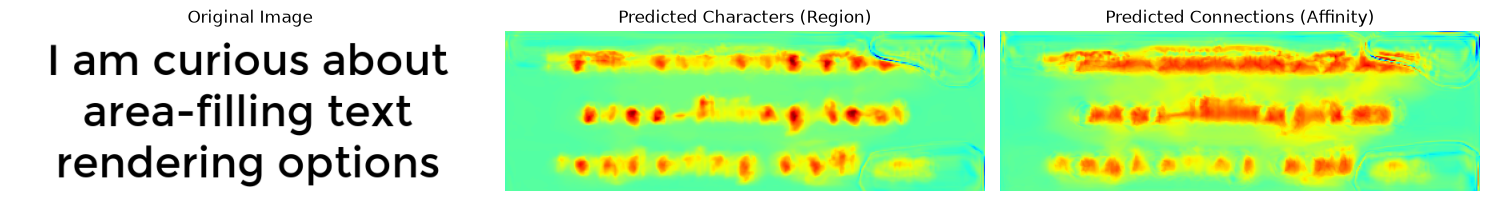

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CRAFT() 
model.load_state_dict(torch.load("./models/CRAFT_10K/craft_epoch2.pth", map_location=device))
model = model.to(device)
model.eval()

image_path = "./images/ocr.jpeg"
raw_img = cv2.imread(image_path)
h, w, _ = raw_img.shape

img_size = 768
scale = img_size / max(h, w)
new_h, new_w = int(h * scale), int(w * scale)
resized_img = cv2.resize(raw_img, (new_w, new_h))

pad_img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
pad_img[:new_h, :new_w] = resized_img

img_tensor = pad_img.astype(np.float32) / 255.0
img_tensor = torch.from_numpy(img_tensor).permute(2, 0, 1).unsqueeze(0).to(device)

with torch.no_grad():
    preds = model(img_tensor)
    preds = preds.permute(0, 3, 1, 2)


hm_h, hm_w = new_h // 2, new_w // 2

pred_region   = preds[0, 0, :hm_h, :hm_w].cpu().numpy()
pred_affinity = preds[0, 1, :hm_h, :hm_w].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(pred_region, cmap="jet")
axes[1].set_title("Predicted Characters (Region)")
axes[1].axis("off")

axes[2].imshow(pred_affinity, cmap="jet")
axes[2].set_title("Predicted Connections (Affinity)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [18]:
def get_text_boxes(pred_region, pred_affinity, original_shape, text_threshold=0.7, link_threshold=0.7):
    """
    Converts CRAFT heatmap predictions into clean word bounding boxes.
    
    Args:
        pred_region (np.ndarray): 2D array of region scores (H/2, W/2)
        pred_affinity (np.ndarray): 2D array of affinity scores (H/2, W/2)
        original_shape (tuple): The (height, width) of the raw input image before resizing
        text_threshold (float): Minimum confidence to consider a pixel a character center
        link_threshold (float): Minimum confidence to consider a pixel a space-bridge
        
    Returns:
        list: A list of bounding boxes, where each box is a list of 4 corner coordinates [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]
    """
    orig_h, orig_w = original_shape[:2]
    hm_h, hm_w = pred_region.shape

    # 1. Thresholding to create binary masks
    text_mask = pred_region > text_threshold
    link_mask = pred_affinity > link_threshold

    # 2. Combine maps to bridge character gaps into whole words
    # Converting to uint8 (0 or 255) for OpenCV processing
    combined_mask = np.logical_or(text_mask, link_mask).astype(np.uint8) * 255

    # 3. Find connected pixel clusters (individual words)
    n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(combined_mask, connectivity=4)

    boxes = []
    
    # Label 0 is always the background cluster, so start at index 1
    for i in range(1, n_labels):
        # Ignore extremely tiny noisy artifacts (e.g., clusters smaller than 10 total pixels)
        if stats[i, cv2.CC_STAT_AREA] < 10:
            continue

        # Isolate the current component mask
        component_mask = (labels == i).astype(np.uint8) * 255
        
        # Find the contours wrapping this word
        contours, _ = cv2.findContours(component_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) == 0:
            continue
            
        contour = contours[0]
        
        # Get the minimal bounding box around the contour (handles rotated text safely)
        rect = cv2.minAreaRect(contour)
        box = cv2.boxPoints(rect) # Outputs 4 corner coordinates
        
        # 4. Scale coordinates back up to the original unpadded image size
        # CRAFT outputs maps at exactly half resolution (H/2, W/2)
        scale_x = orig_w / hm_w
        scale_y = orig_h / hm_h
        
        box[:, 0] *= scale_x
        box[:, 1] *= scale_y
        
        boxes.append(box.astype(np.int32).tolist())
        
    return boxes

In [19]:
boxes = get_text_boxes(pred_region, pred_affinity, raw_img.shape)

for box in boxes:
    # Reshape coordinates into a format cv2.polylines expects
    pts = np.array(box, np.int32).reshape((-1, 1, 2))
    # Draw a bright green bounding polygon around the detected word
    cv2.polylines(raw_img, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

# Save or display your results
cv2.imwrite("detected_words.jpg", raw_img)

True